# 펭귄 데이터(기계학습 분류 실습)

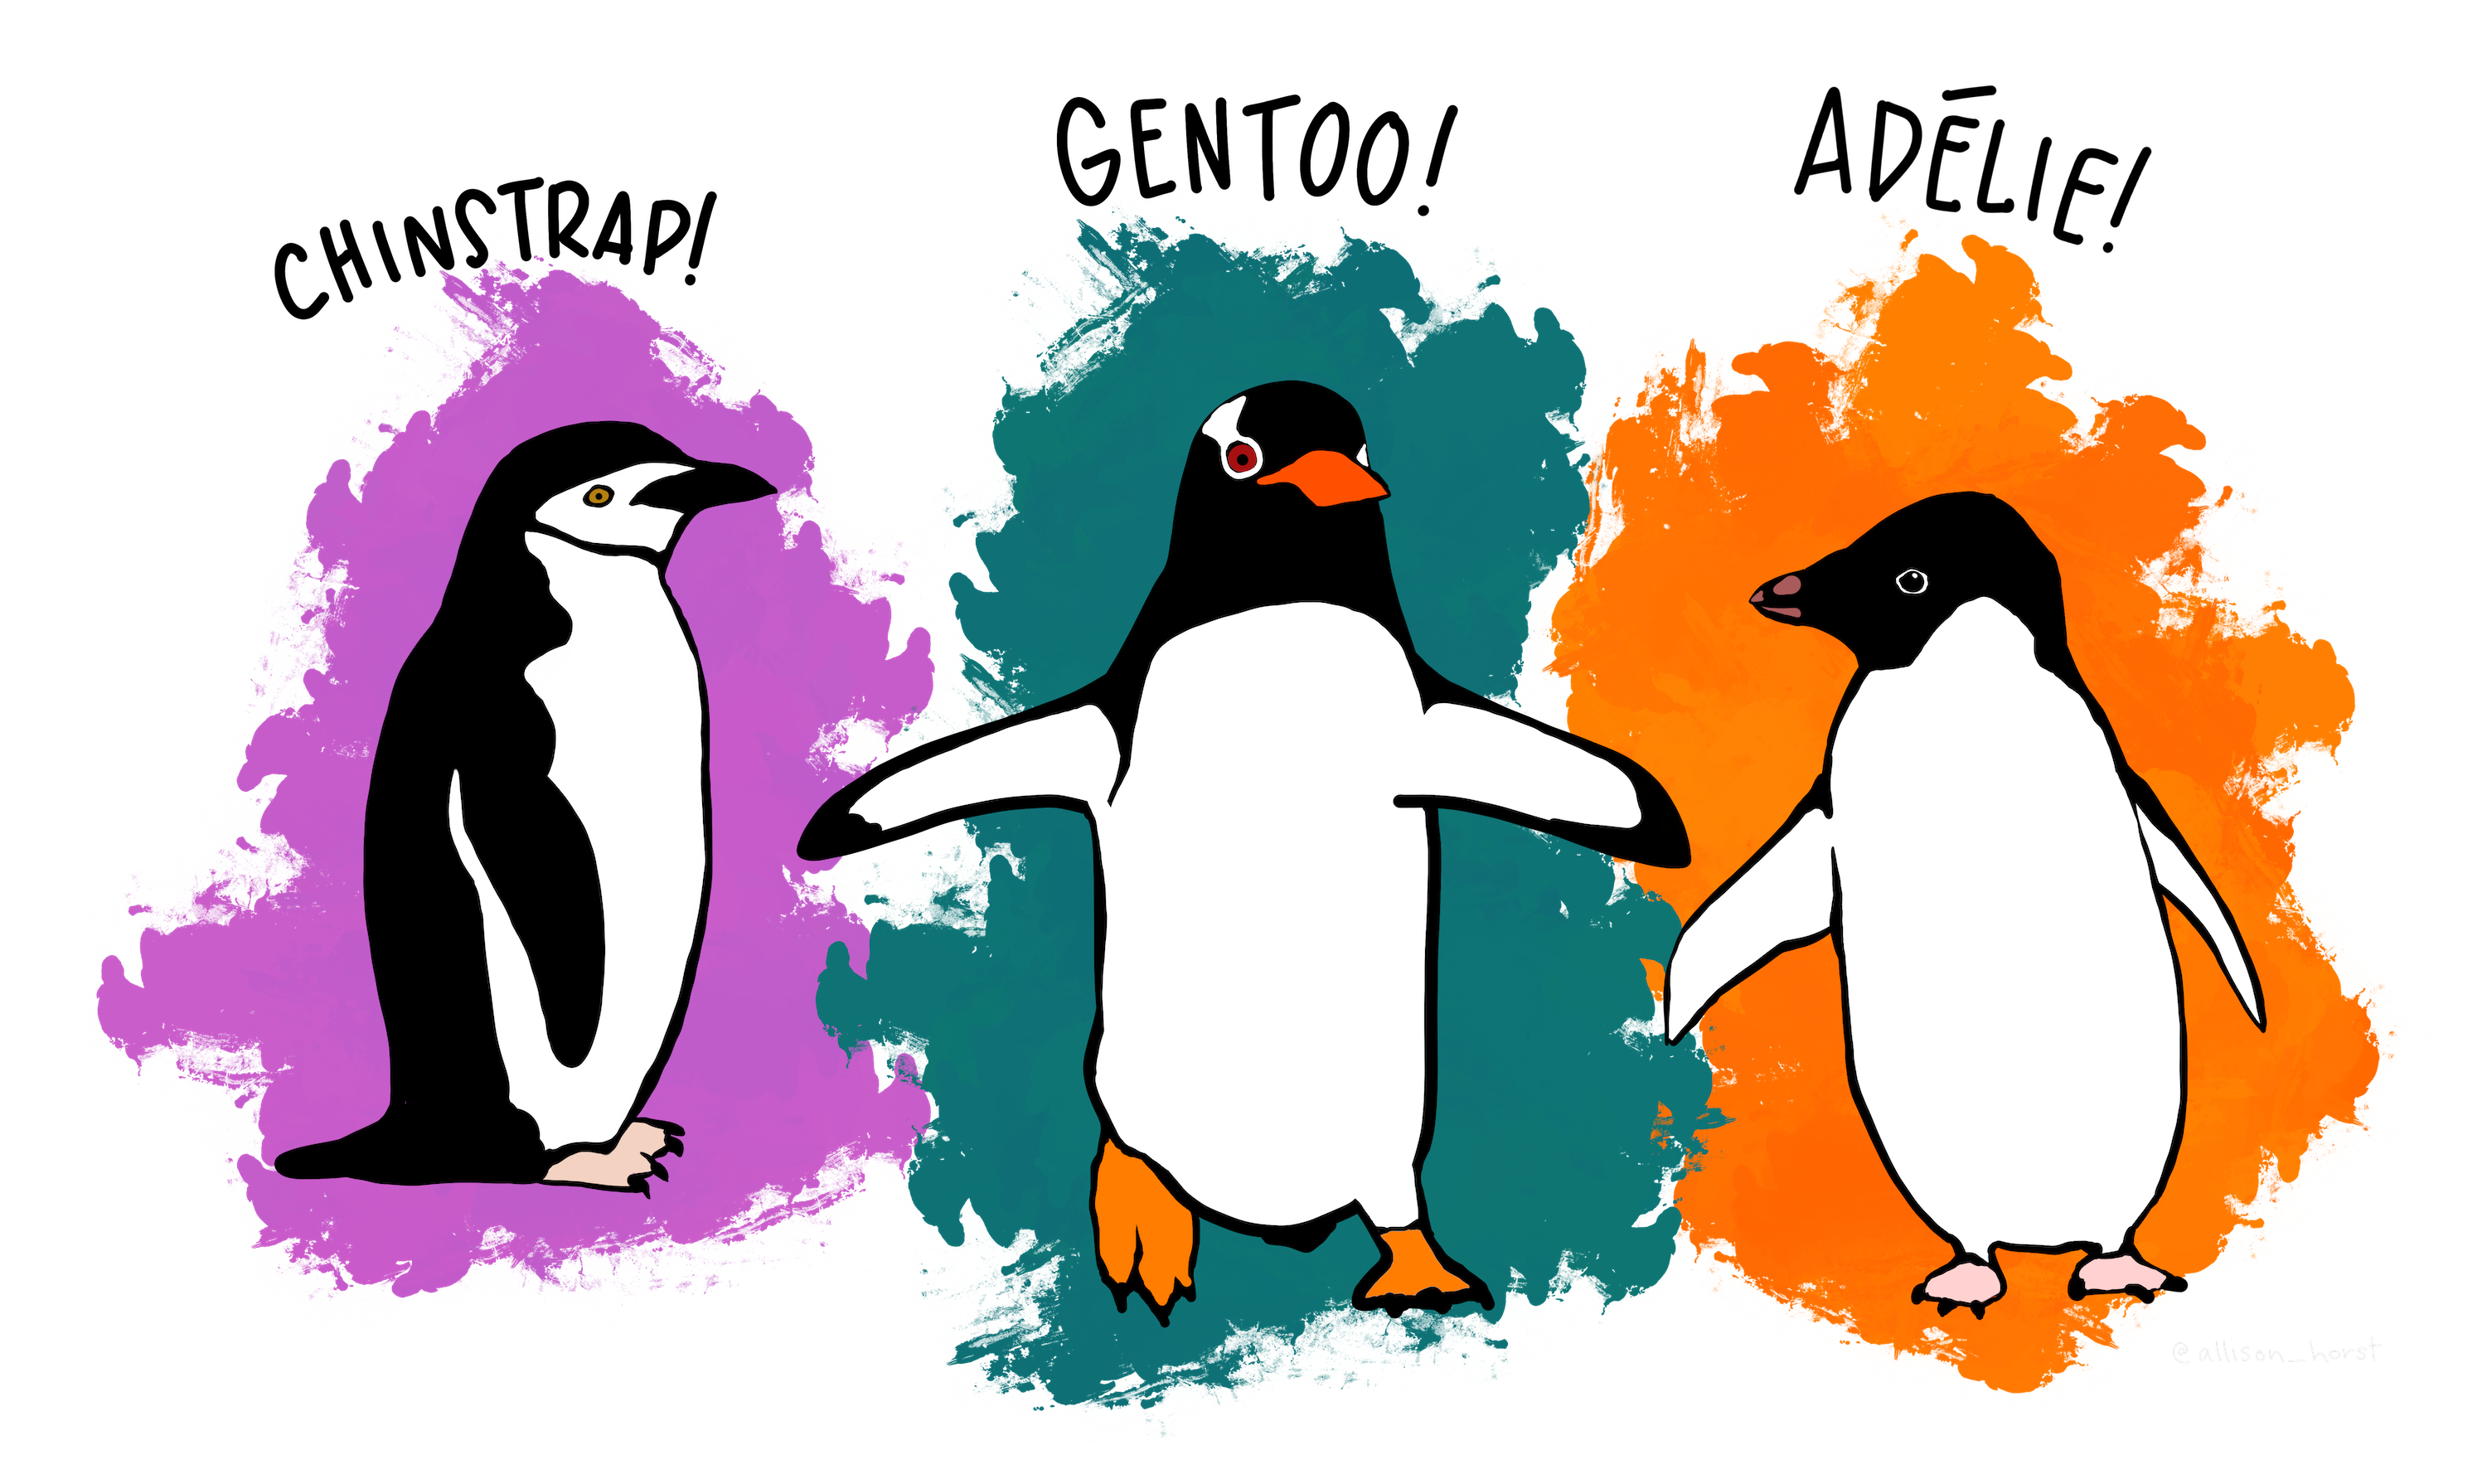

## 1. 데이터 수집하기
- 남극의 Palmer Archipelago 지역에 서식하는 펭귄 3종에 대한 정보를 기록한 데이터셋
- 출처 : https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data

## 2. 데이터 살펴보기

In [ ]:
# 펭귄 데이터(penguins_size) 불러오기(p79)
import pandas as pd

df = _____________
df

In [ ]:
# 데이터의 속성과 유형 살펴보기(p79)

_____________

In [ ]:
# 데이터의 통계 정보 확인하기(p79)

_____________

In [ ]:
# 데이터 시각화하기(p80)
# seaborn의 막대그래프 사용해서 펭귄 종의 데이터 수 시각화하기
import seaborn as sns

sns._____________

## 3. 데이터 전처리

In [ ]:
# 결측치 확인하기(p80)
# NaN 값이 속성마다 얼마나 있는지 확인

df._____________

[ 결측치를 처리하는 방법 ]
- 평균값으로 채우기
- 앞/뒤의 값으로 채우기
- 행/열 삭제하기

In [ ]:
# 결측치가 있는 행 제거하기(p80)

df = df._____________
df.shape

In [ ]:
# 이상치 확인하기(p81)
# 속성: culmen_length_mm
import seaborn as sns

sns._____________

In [ ]:
# 다른 속성들의 이상치 여부 확인하기


In [ ]:
# 속성들의 고유한 값을 확인하며 이상치 여부 확인하기(p81)
# 속성: species

_____________

In [ ]:
# 속성들의 고유한 값을 확인하며 이상치 여부 확인하기(p81)
# 속성: sex
_____________

In [ ]:
# 성별의 이상치 확인하기(p81)

_____________

In [ ]:
# 이상치 데이터 제거하고 확인하기(p81)

df = _____________
df["sex"].unique()

[ 이상치 제거하기 ]
- drop(336, axis=0)
- df[df["sex"] != "."]

In [ ]:
# 데이터 정규화하기(p82)
# 사용할 방식: MinMax 정규화
from sklearn.preprocessing import MinMaxScaler

scaler = _____________

col = ["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g"]
df[col] = scaler._____________(df[col])

df.head(10)

## 4. 핵심 속성 추출하기

In [ ]:
# 산점도를 사용하여 상관관계 분석하기(p82)
# 부리 길이(culmen_length_mm)와 부리 깊이(culmen_depth_mm) 간의 상관관계

import seaborn as sns

sns.scatterplot(____________________________________________________)

In [ ]:
# 산점도를 사용하여 상관관계 분석하기(p82)
# 부리 깊이(culmen_depth_mm)와 날개 길이(flipper_length_mm) 간의 상관관계

____________________________________________________

In [ ]:
# 산점도와 회귀선으로 상관관계 및 회귀선 확인하기(p83)
# 부리 길이(culmen_length_mm)와 체질량(body_mass_g)의 상관관계 확인하기

sns.regplot(____________________________________________________)

In [ ]:
# 히트맵을 사용하여 전체 속성 사이의 상관관계 분석하기(p83)

sns.heatmap(____________________________________________________)

## 5. 훈련에 사용할 데이터 준비하기

In [ ]:
# 특징과 타깃 설정하기(p111)
# 특징(X): 예측에 사용할 속성
# 타깃(y): 예측하려는 속성

X = df[____________________________________________________]
y = df[____________]

X, y

In [ ]:
# 훈련용 데이터와 검증용 데이터로 분할하기(p111)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = ___________________________________

## 6. 기계학습 모델 생성 및 평가하기

In [ ]:
# 결정트리 모델 생성하고 정확도 구하기(p112)

from sklearn.tree import DecisionTreeClassifier

# 모델 학습
dt = ________________________
dt.________________________

# 모델의 정확도
print("훈련용 데이터의 정확도:", dt.________________________)

In [ ]:
# 생성한 결정트리 모델 시각화하기(p112)
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 그래프 크기 조정
plt.figure(figsize=(20, 10))

# 결정트리 시각화
plot_tree(dt, feature_names=X.columns, max_depth=2, filled=True)
plt.show()

In [ ]:
# 검증용 데이터를 활용해 예측하기(p112)

print("결정트리 성능 평가:", dt.________________________)

In [ ]:
# 혼동행렬 확인하기(p115)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 혼동행렬 생성
conf = confusion_matrix(y_test, dt.predict(X_test))

# 혼동행렬을 히트맵으로 변환
sns.heatmap(conf, annot=True, cmap="Blues")

plt.title("Penguin Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()